In [1]:
# ==========================================================
# 04_shap_stability_analysis_MAR_logisticRegression.py
# Corrected Version
# Full Dataset MAR + KNN + Rank-Based SHAP Stability
# ==========================================================

import pandas as pd
import numpy as np
import os
import shap
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ----------------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------------
file_path = "../dataset/clean_dengue_dataset.csv"
df = pd.read_csv(file_path)

# ----------------------------------------------------------
# 2. Load Baseline SHAP Importance
# ----------------------------------------------------------
baseline_path = "outputs/baseline_logisticRegression_shap_importance.csv"
baseline_df = pd.read_csv(baseline_path)

# ----------------------------------------------------------
# 3. Separate Features and Target
# ----------------------------------------------------------
target_column = "dengue_label"

X = df.drop(columns=[target_column])
y = df[target_column]

feature_names = X.columns.tolist()

# ----------------------------------------------------------
# 4. Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# ----------------------------------------------------------
# 5. Create Output Folders
# ----------------------------------------------------------
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)


/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ----------------------------------------------------------
# 6. Full Dataset MAR Function
# ----------------------------------------------------------
def inject_mar_missingness(df_input, level, random_state=42):

    np.random.seed(random_state)

    df_missing = df_input.copy()

    n = len(df_missing)

    for i in range(n):

        # age high -> hemoglobin missing
        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] > 50:
                if np.random.rand() < level:
                    df_missing.loc[i, "hemoglobin_g_dl"] = np.nan

        # platelet low -> wbc missing
        if pd.notnull(df_missing.loc[i, "platelet_count"]):
            if df_missing.loc[i, "platelet_count"] < 80000:
                if np.random.rand() < level:
                    df_missing.loc[i, "wbc_count"] = np.nan

        # female -> rbc missing
        if df_missing.loc[i, "gender"] == 1:
            if np.random.rand() < level:
                df_missing.loc[i, "rbc_count"] = np.nan

        # child -> age missing
        if df_missing.loc[i, "gender"] == 2:
            if np.random.rand() < level:
                df_missing.loc[i, "age"] = np.nan

        # low WBC -> differential missing
        if pd.notnull(df_missing.loc[i, "wbc_count"]):
            if df_missing.loc[i, "wbc_count"] < 3000:
                if np.random.rand() < level:
                    df_missing.loc[i, "differential_count"] = np.nan

        # low hemoglobin -> platelet missing
        if pd.notnull(df_missing.loc[i, "hemoglobin_g_dl"]):
            if df_missing.loc[i, "hemoglobin_g_dl"] < 12:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_count"] = np.nan

        # high pdw -> rbc missing
        if pd.notnull(df_missing.loc[i, "platelet_distribution_width"]):
            if df_missing.loc[i, "platelet_distribution_width"] > 16:
                if np.random.rand() < level:
                    df_missing.loc[i, "rbc_count"] = np.nan

        # age below 18 -> pdw missing
        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] < 18:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_distribution_width"] = np.nan

    return df_missing

# ----------------------------------------------------------
# 7. Function: Compute SHAP Importance
# ----------------------------------------------------------
def compute_shap_importance(model, X_train_scaled, X_test_scaled):

    explainer = shap.LinearExplainer(model, X_train_scaled)

    shap_values = explainer.shap_values(X_test_scaled)

    importance = np.abs(shap_values).mean(axis=0)

    result = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    return result

# ----------------------------------------------------------
# 8. Baseline Ranking
# ----------------------------------------------------------
baseline_df["Rank_Baseline"] = baseline_df["Importance"].rank(
    ascending=False,
    method="average"
)

# ----------------------------------------------------------
# 9. MAR Levels
# ----------------------------------------------------------
mar_levels = [0.05, 0.10, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8]

stability_results = []
all_importance = []

# ----------------------------------------------------------
# 10. Loop Through Levels
# ----------------------------------------------------------
for level in mar_levels:

    print("=" * 60)
    print(f"Processing MAR Level: {int(level*100)}%")
    print("=" * 60)

    # --------------------------------------
    # Inject Missingness
    # --------------------------------------
    X_train_mar = inject_mar_missingness(X_train, level)

    missing_count = X_train_mar.isnull().sum().sum()

    # --------------------------------------
    # KNN Imputation
    # --------------------------------------
    imputer = KNNImputer(n_neighbors=5)

    X_train_imp = imputer.fit_transform(X_train_mar)
    X_test_imp = imputer.transform(X_test)

    # --------------------------------------
    # Scaling
    # --------------------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    # --------------------------------------
    # Train Model
    # --------------------------------------
    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # --------------------------------------
    # Compute SHAP Importance
    # --------------------------------------
    current_df = compute_shap_importance(
        model,
        X_train_scaled,
        X_test_scaled
    )

    current_df["Rank_MAR"] = current_df["Importance"].rank(
        ascending=False,
        method="average"
    )

    current_df["MAR_Level"] = int(level * 100)

    all_importance.append(current_df)

    # --------------------------------------
    # Merge Baseline vs Current
    # --------------------------------------
    merged = baseline_df.merge(
        current_df,
        on="Feature",
        suffixes=("_Baseline", "_MAR")
    )

    # --------------------------------------
    # Rank-Based Spearman Correlation
    # --------------------------------------
    corr, _ = spearmanr(
        merged["Rank_Baseline"],
        merged["Rank_MAR"]
    )

    stability_results.append({
        "MAR_Level": int(level * 100),
        "Missing_Values": missing_count,
        "Spearman_Correlation": corr
    })

    print(f"Missing Values : {missing_count}")
    print(f"SHAP Stability : {corr:.4f}")

# ----------------------------------------------------------
# 11. Save Results
# ----------------------------------------------------------
stability_df = pd.DataFrame(stability_results)

stability_df.to_csv(
    "outputs/logisticRegression_MAR_shap_stability.csv",
    index=False
)

importance_df = pd.concat(all_importance)

importance_df.to_csv(
    "outputs/logisticRegression_MAR_feature_importance.csv",
    index=False
)

print("\nCSV files saved successfully.")

Processing MAR Level: 5%
Missing Values : 146
SHAP Stability : 0.9762
Processing MAR Level: 10%
Missing Values : 248
SHAP Stability : 1.0000
Processing MAR Level: 20%
Missing Values : 432
SHAP Stability : 0.9048
Processing MAR Level: 30%
Missing Values : 593
SHAP Stability : 1.0000
Processing MAR Level: 40%
Missing Values : 744
SHAP Stability : 0.8571
Processing MAR Level: 50%
Missing Values : 881
SHAP Stability : 0.6190
Processing MAR Level: 60%
Missing Values : 1003
SHAP Stability : 0.5476
Processing MAR Level: 70%
Missing Values : 1159
SHAP Stability : 0.5476
Processing MAR Level: 80%
Missing Values : 1250
SHAP Stability : 0.5952

CSV files saved successfully.


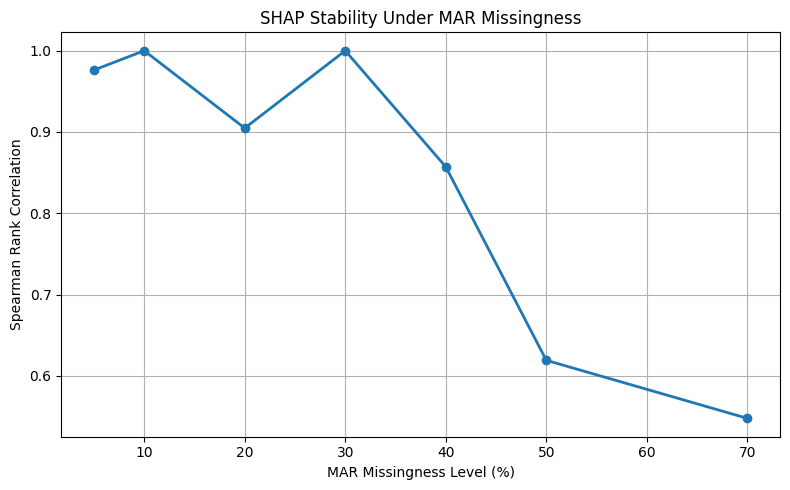

Plot saved successfully.

PROCESS COMPLETED SUCCESSFULLY


In [6]:

# ----------------------------------------------------------
# 12. Plot Stability Graph
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(
    stability_df["MAR_Level"],
    stability_df["Spearman_Correlation"],
    marker="o",
    linewidth=2
)

plt.title("SHAP Stability Under MAR Missingness")
plt.xlabel("MAR Missingness Level (%)")
plt.ylabel("Spearman Rank Correlation")
plt.grid(True)

plt.tight_layout()
plt.show()

# plt.savefig(
#     "outputs/plots/logisticRegression_MAR_shap_stability.png",
#     dpi=300
# )

plt.close()

print("Plot saved successfully.")

print("\nPROCESS COMPLETED SUCCESSFULLY")